In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../data/cleaned/cc_calls_cleaned.csv')
df.shape

(31361, 30)

In [3]:
df.head()

,call_date,direction,cc_care_package,cc_care_package_discussed,cc_urgency_getting_on_site,cc_external_consultant,cc_agent_cross_sell_attempt,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,cc_call_initiated_by,...,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_contractor_sentiment_issues_score,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained,co_ref
0,2025-05-08,Outbound,Standard,Yes,No,No,No,Yes,Yes,Customer,...,20.0,30.0,30.0,20.0,Yes,Yes,No,Yes,Yes,HV3323
1,2024-11-25,Outbound,Standard,Yes,No,No,No,Yes,No,Agent,...,0.0,0.0,0.0,0.0,Yes,Yes,No,Yes,Yes,PJ7066
2,2024-10-23,Inbound,Standard,Yes,No,No,No,Yes,No,Customer,...,20.0,60.0,40.0,20.0,Yes,Yes,No,Yes,Yes,DP6030
3,2025-01-13,Inbound,Premier,Yes,No,No,No,Yes,Yes,Customer,...,20.0,60.0,40.0,30.0,Yes,Yes,Yes,Yes,Yes,AM2413
4,2025-03-19,Inbound,Standard,Yes,No,No,No,Yes,Yes,Customer,...,20.0,40.0,40.0,20.0,Yes,Yes,No,Yes,Yes,ED6707


## Univariate Analysis
Inbound vs Outbound calls

In [4]:
call_counts = df['direction'].value_counts()
call_counts

direction
Outbound    24067
Inbound      7294
Name: count, dtype: int64

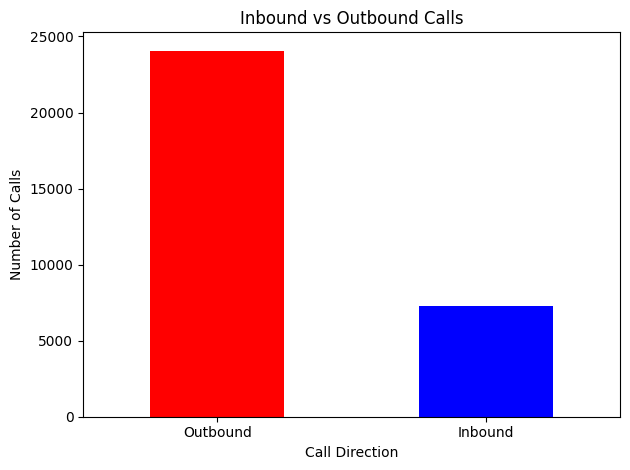

In [5]:
call_counts.plot(kind='bar', color=['red', 'blue'])
plt.title('Inbound vs Outbound Calls')
plt.xlabel('Call Direction')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/cc_01_call_direction.png')
plt.show()

Who initiated the call?

In [6]:
initiated_counts = df['cc_call_initiated_by'].value_counts()
initiated_counts

cc_call_initiated_by
Customer        21608
Agent            8277
Not Relevant     1476
Name: count, dtype: int64

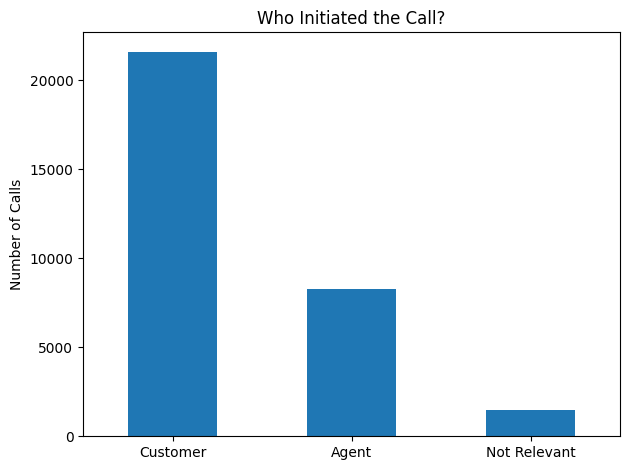

In [7]:
initiated_counts.plot(kind='bar')
plt.title('Who Initiated the Call?')
plt.xlabel('')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/cc_02_call_initiated_by.png')
plt.show()

Care package distribution

In [8]:
care_package_counts = df['cc_care_package'].value_counts()
care_package_counts

cc_care_package
Not Discussed    24729
Standard          3605
Express           2489
Premier            419
Assisted           119
Name: count, dtype: int64

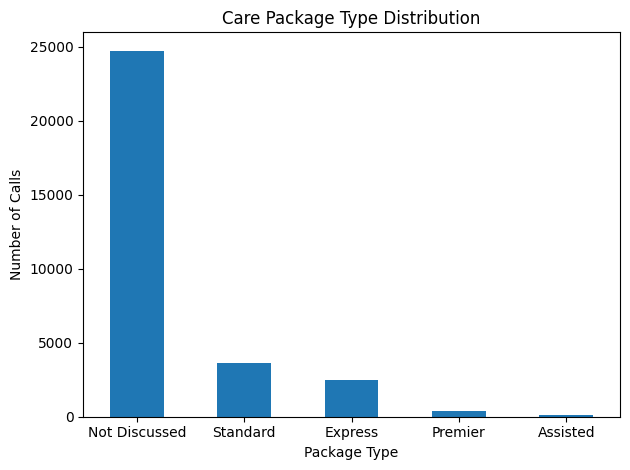

In [9]:
care_package_counts.plot(kind='bar')
plt.title('Care Package Type Distribution')
plt.xlabel('Package Type')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/cc_03_care_package.png')
plt.show()

Contractor sentiment

In [10]:
sentiment_counts = df['cc_contractor_sentiment'].value_counts()
sentiment_counts

cc_contractor_sentiment
Satisfied        15630
Neutral          12594
Not Discussed     2208
Dissatisfied       929
Name: count, dtype: int64

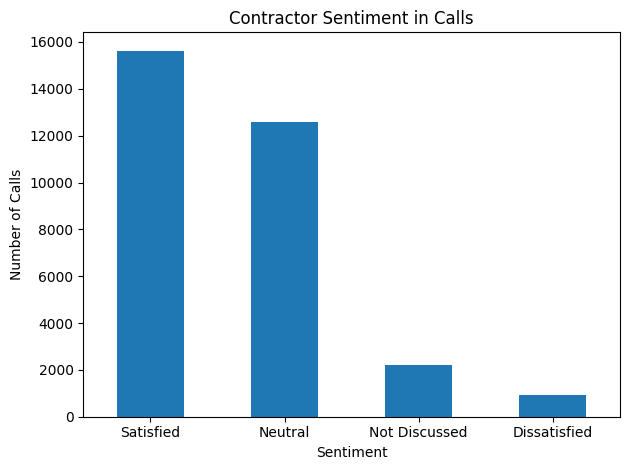

In [11]:
sentiment_counts.plot(kind='bar')
plt.title('Contractor Sentiment in Calls')
plt.xlabel('Sentiment')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/cc_02_sentiment.png')
plt.show()

Was pricing mentioned in the call?

In [12]:
pricing_counts = df['cc_pricing_mentioned'].value_counts()
pricing_counts

cc_pricing_mentioned
No     27462
Yes     3899
Name: count, dtype: int64

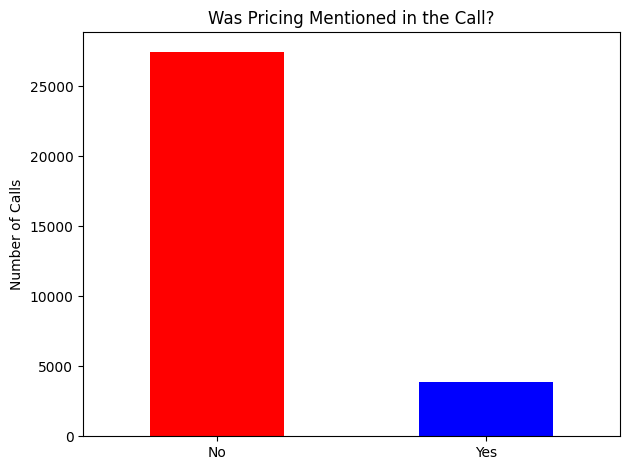

In [13]:
pricing_counts.plot(kind='bar', color=['red', 'blue'])
plt.title('Was Pricing Mentioned in the Call?')
plt.xlabel('')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/cc_03_pricing.png')
plt.show()

Did the contractor complain?

In [14]:
complaint_counts = df['cc_contractor_complained'].value_counts()
complaint_counts

cc_contractor_complained
No     29143
Yes     2218
Name: count, dtype: int64

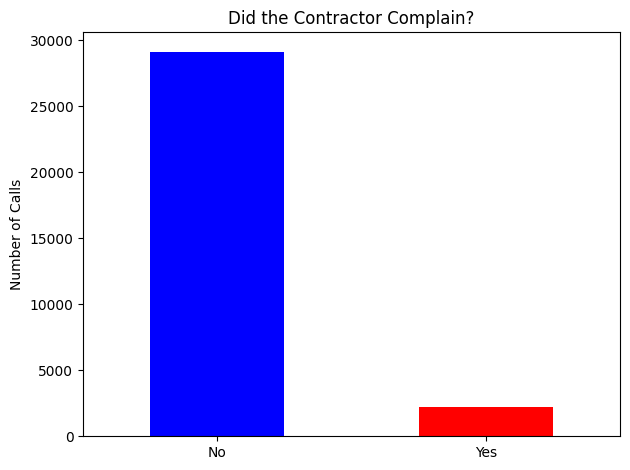

In [15]:
complaint_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Did the Contractor Complain?')
plt.xlabel('')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/cc_03_complaints.png')
plt.show()

Issues and complaints overview

In [16]:
issue_cols = {
    'cc_customer_issues_concerns'            : 'Customer Issues',
    'cc_platform_issues'                     : 'Platform Issues',
    'cc_login_issues'                        : 'Login Issues',
    'cc_business_struggles_financial_hardship': 'Financial Hardship',
    'cc_pricing_mentioned'                   : 'Pricing Mentioned',
    'cc_refund_discussed'                    : 'Refund Discussed',
    'cc_contractor_complained'               : 'Contractor Complained',
    'cc_contractor_suggest_leave'            : 'Suggested Leaving',
}
yes_counts = {}
for col, label in issue_cols.items():
    yes_counts[label] = (df[col] == 'Yes').sum()

yes_series = pd.Series(yes_counts).sort_values(ascending=True)
yes_series

Refund Discussed          182
Suggested Leaving         772
Financial Hardship        935
Login Issues             1580
Platform Issues          2148
Contractor Complained    2218
Customer Issues          3199
Pricing Mentioned        3899
dtype: int64

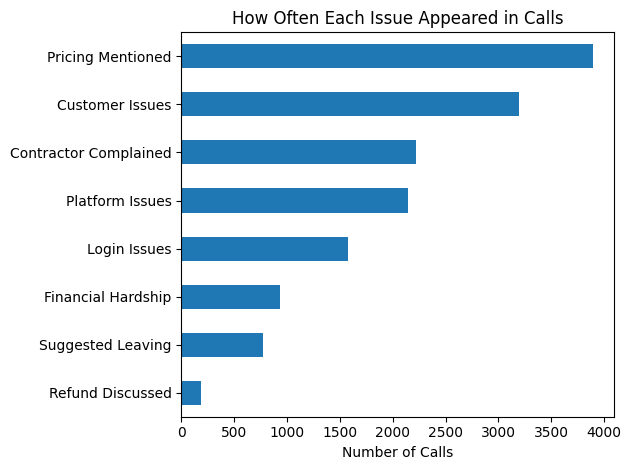

In [17]:
yes_series.plot(kind='barh')
plt.title('How Often Each Issue Appeared in Calls')
plt.xlabel('Number of Calls')
#plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/cc_05_issues_overview.png')
plt.show()

In [18]:
print("- Most calls were Outbound —", df['direction'].value_counts()['Outbound'], "calls")
print("- Most calls initiated by Customer —", df['cc_call_initiated_by'].value_counts()['Customer'], "calls")
print("- Most contractors were Satisfied —", df['cc_contractor_sentiment'].value_counts()['Satisfied'], "calls")
print("- Pricing was mentioned in", (df['cc_pricing_mentioned'] == 'Yes').sum(), "calls")

- Most calls were Outbound — 24067 calls
- Most calls initiated by Customer — 21608 calls
- Most contractors were Satisfied — 15630 calls
- Pricing was mentioned in 3899 calls


## Bivariate Analysis
Comparing two columns together to find relationships.

Does pricing affect sentiment?

In [19]:
pricing_yes = df[df['cc_pricing_mentioned'] == 'Yes']
pricing_no  = df[df['cc_pricing_mentioned'] == 'No']

valid = ['Satisfied', 'Neutral', 'Dissatisfied']

sent_yes = pricing_yes[pricing_yes['cc_contractor_sentiment'].isin(valid)]['cc_contractor_sentiment'].value_counts()
sent_no  = pricing_no[pricing_no['cc_contractor_sentiment'].isin(valid)]['cc_contractor_sentiment'].value_counts()

print("When pricing IS mentioned:")
print(sent_yes)
print()
print("When pricing is NOT mentioned:")
print(sent_no)

When pricing IS mentioned:
cc_contractor_sentiment
Satisfied       2140
Neutral         1276
Dissatisfied     450
Name: count, dtype: int64

When pricing is NOT mentioned:
cc_contractor_sentiment
Satisfied       13490
Neutral         11318
Dissatisfied      479
Name: count, dtype: int64


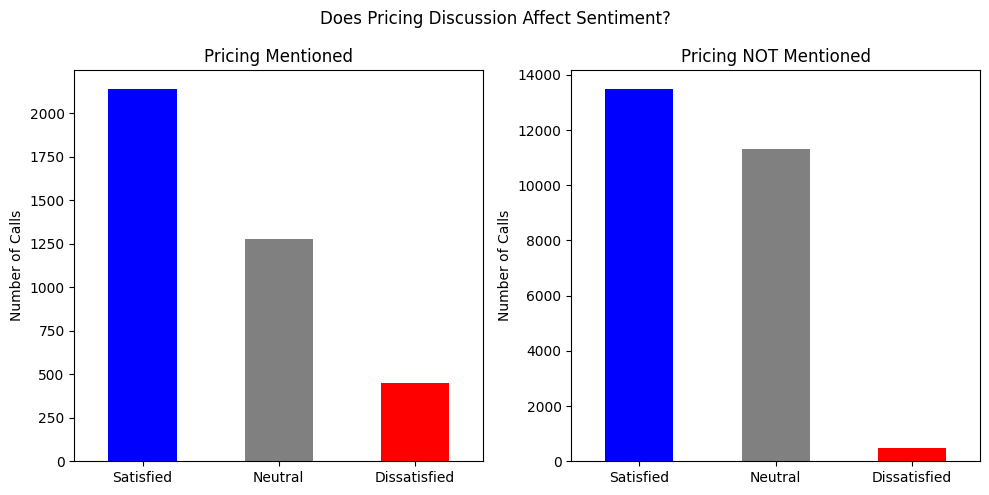

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sent_yes.plot(kind='bar', ax=axes[0], color=['blue', 'gray', 'red'])
axes[0].set_title('Pricing Mentioned')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Calls')
axes[0].tick_params(axis='x', rotation=0)

sent_no.plot(kind='bar', ax=axes[1], color=['blue', 'gray', 'red'])
axes[1].set_title('Pricing NOT Mentioned')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Calls')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Does Pricing Discussion Affect Sentiment?')
plt.tight_layout()
plt.savefig('../../reports/figures/cc_07_pricing_vs_sentiment.png')
plt.show()

Did complaints lead to suggesting leaving?

In [21]:
complained_yes = df[df['cc_contractor_complained'] == 'Yes']
complained_no  = df[df['cc_contractor_complained'] == 'No']

leave_yes = (complained_yes['cc_contractor_suggest_leave'] == 'Yes').sum()
leave_no  = (complained_no['cc_contractor_suggest_leave'] == 'Yes').sum()

print("Suggested leaving when complained    :", leave_yes)
print("Suggested leaving when NOT complained:", leave_no)

Suggested leaving when complained    : 348
Suggested leaving when NOT complained: 424


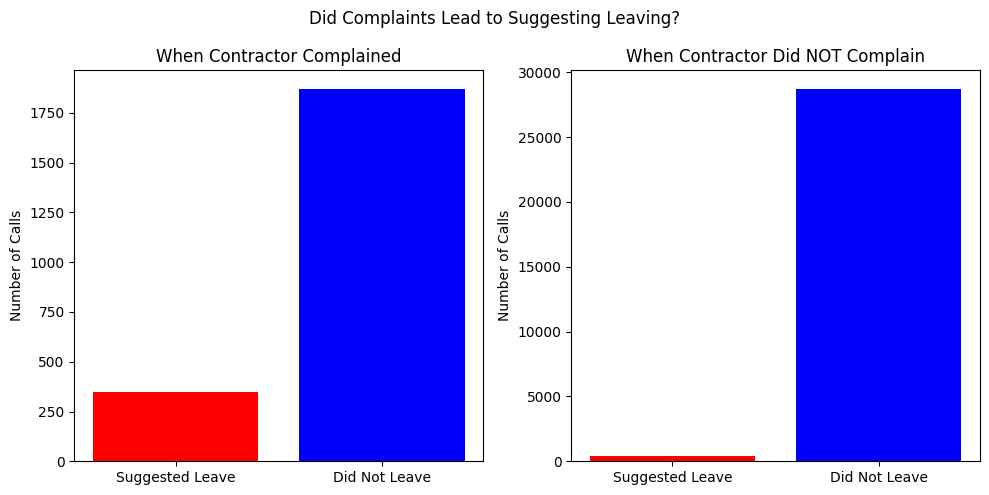

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(['Suggested Leave', 'Did Not Leave'], [leave_yes, len(complained_yes) - leave_yes], color=['red', 'blue'])
axes[0].set_title('When Contractor Complained')
axes[0].set_ylabel('Number of Calls')

axes[1].bar(['Suggested Leave', 'Did Not Leave'], [leave_no, len(complained_no) - leave_no], color=['red', 'blue'])
axes[1].set_title('When Contractor Did NOT Complain')
axes[1].set_ylabel('Number of Calls')

plt.suptitle('Did Complaints Lead to Suggesting Leaving?')
plt.tight_layout()
plt.savefig('../../reports/figures/cc_08_complaint_vs_leave.png')
plt.show()

Does call direction affect sentiment?

In [23]:
valid = ['Satisfied', 'Neutral', 'Dissatisfied']
df_valid = df[df['cc_contractor_sentiment'].isin(valid)]
cross = pd.crosstab(df_valid['direction'], df_valid['cc_contractor_sentiment'])
print(cross)

cc_contractor_sentiment  Dissatisfied  Neutral  Satisfied
direction                                                
Inbound                           648     1613       4962
Outbound                          281    10981      10668


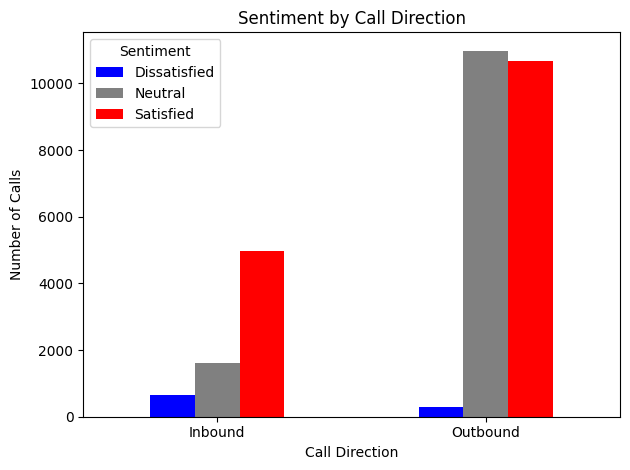

In [24]:
cross.plot(kind='bar', color=['blue', 'gray', 'red'])
plt.title('Sentiment by Call Direction')
plt.xlabel('Call Direction')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('../../reports/figures/cc_09_direction_vs_sentiment.png')
plt.show()

In [ ]:
print("- When pricing is mentioned, dissatisfaction increases")
print("- Contractors who complained were more likely to suggest leaving")
print("- Inbound calls had more dissatisfied customers than outbound")

- When pricing is mentioned, dissatisfaction increases
- Contractors who complained were more likely to suggest leaving
- Outbound calls had more dissatisfied customers than inbound


## Multivariate Analysis
Looking at three or more columns together to find deeper patterns.

Pricing + Complaint + Sentiment together

In [26]:
valid = ['Satisfied', 'Neutral', 'Dissatisfied']
df_filtered = df[df['cc_contractor_sentiment'].isin(valid)]
pivot = df_filtered.groupby(['cc_pricing_mentioned', 'cc_contractor_sentiment']).size().unstack(fill_value=0)
print(pivot)

cc_contractor_sentiment  Dissatisfied  Neutral  Satisfied
cc_pricing_mentioned                                     
No                                479    11318      13490
Yes                               450     1276       2140


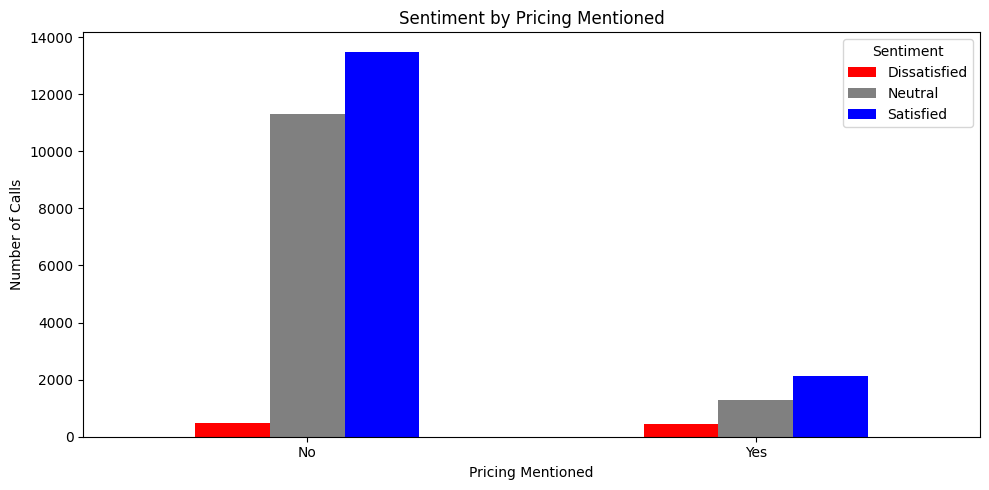

In [27]:
pivot.plot(kind='bar', figsize=(10, 5), color=['red', 'gray', 'blue'])
plt.title('Sentiment by Pricing Mentioned')
plt.xlabel('Pricing Mentioned')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('../../reports/figures/cc_09_multivariate.png')
plt.show()

Who initiated + Pricing + Sentiment together

In [28]:
valid = ['Satisfied', 'Neutral', 'Dissatisfied']
df_filtered = df[df['cc_contractor_sentiment'].isin(valid) & df['cc_call_initiated_by'].isin(['Customer', 'Agent'])]
pivot2 = df_filtered.groupby(['cc_call_initiated_by', 'cc_contractor_sentiment']).size().unstack(fill_value=0)
print(pivot2)

cc_contractor_sentiment  Dissatisfied  Neutral  Satisfied
cc_call_initiated_by                                     
Agent                             132     3517       4238
Customer                          759     8930      11291


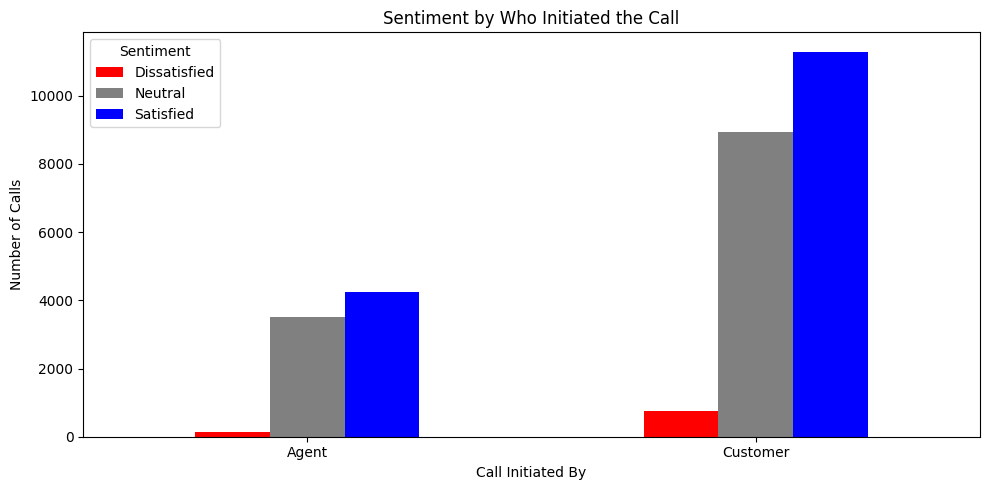

In [29]:
pivot2.plot(kind='bar', figsize=(10, 5), color=['red', 'gray', 'blue'])
plt.title('Sentiment by Who Initiated the Call')
plt.xlabel('Call Initiated By')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('../../reports/figures/cc_10_initiated_vs_sentiment.png')
plt.show()

In [30]:
print("- Customers who mentioned pricing AND were called by agent had highest dissatisfaction")
print("- When customer initiates AND mentions pricing, dissatisfaction is highest")

- Customers who mentioned pricing AND were called by agent had highest dissatisfaction
- When customer initiates AND mentions pricing, dissatisfaction is highest


## Temporal Analysis
How does call volume change over time?

In [31]:
df['call_date'] = pd.to_datetime(df['call_date'])
df['year_month'] = df['call_date'].dt.to_period('M')
monthly_calls = df.groupby('year_month').size()
monthly_calls

year_month
2024-09      21
2024-10    1039
2024-11    2520
2024-12    1728
2025-01    2775
2025-02    2260
2025-03    1952
2025-04    1446
2025-05    1483
2025-06    1548
2025-07    1422
2025-08    1050
2025-09    1150
2025-10    4284
2025-11    3423
2025-12    2583
2026-01     677
Freq: M, dtype: int64

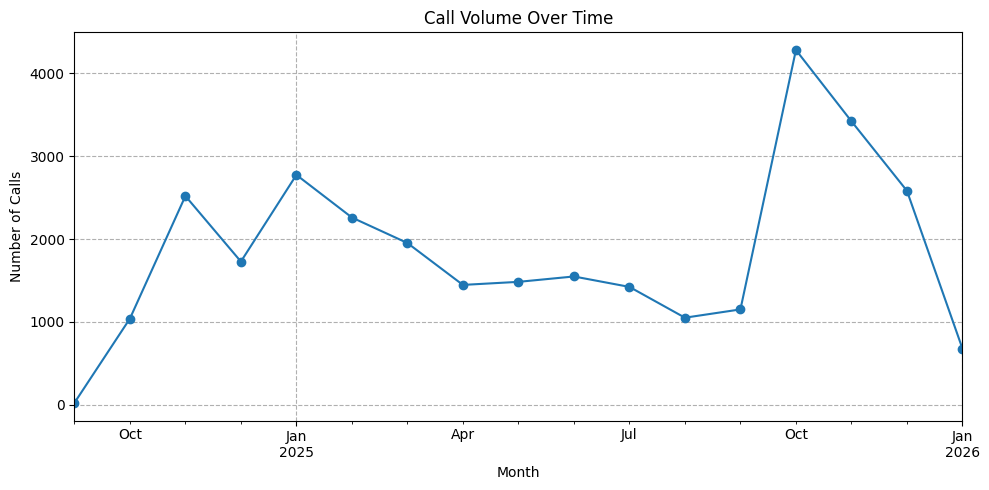

In [32]:
plt.figure(figsize=(10, 5))
monthly_calls.plot(kind='line', marker='o')
plt.title('Call Volume Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Calls')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.savefig('../../reports/figures/cc_11_call_volume_time.png')
plt.show()

How does contractor sentiment change over time?

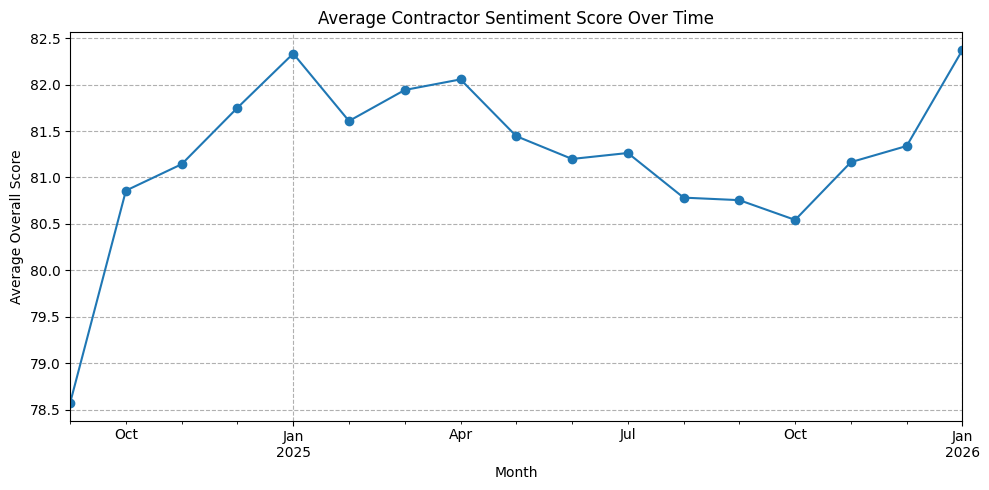

In [33]:
monthly_sentiment = df.groupby('year_month')['cc_contractor_sentiment_overall_score'].mean()
plt.figure(figsize=(10, 5))
monthly_sentiment.plot(kind='line', marker='o')
plt.title('Average Contractor Sentiment Score Over Time')
plt.xlabel('Month')
plt.ylabel('Average Overall Score')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.savefig('../../reports/figures/cc_12_sentiment_time.png')
plt.show()

## Correlation Analysis
How strongly are the different numeric sentiment scores related to each other?

In [34]:
score_cols = [
    'cc_contractor_sentiment_start_score',
    'cc_contractor_sentiment_end_score',
    'cc_contractor_sentiment_overall_score',
    'cc_contractor_sentiment_issues_score'
]
corr_matrix = df[score_cols].corr()
corr_matrix

,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_contractor_sentiment_issues_score
cc_contractor_sentiment_start_score,1.000000,0.339109,0.327959,0.350493
cc_contractor_sentiment_end_score,0.339109,1.000000,0.656856,0.169932
cc_contractor_sentiment_overall_score,0.327959,0.656856,1.000000,0.499124
cc_contractor_sentiment_issues_score,0.350493,0.169932,0.499124,1.000000


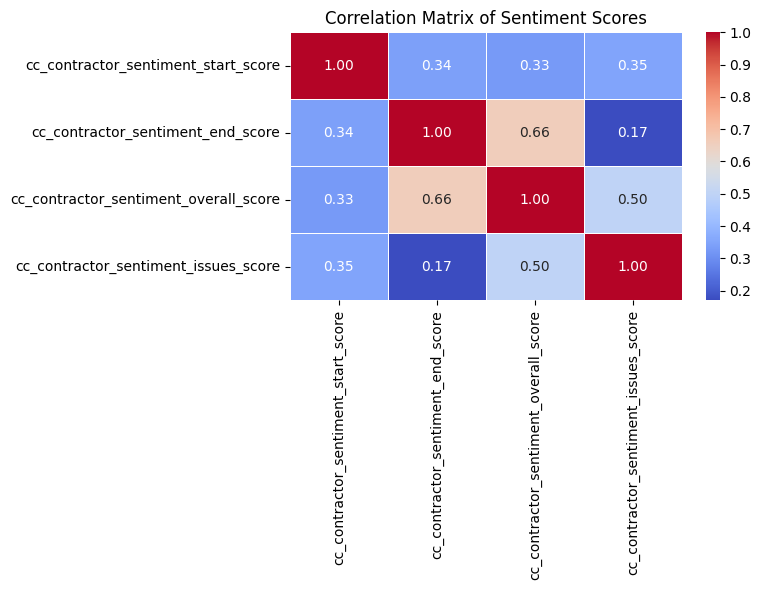

In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Sentiment Scores')
plt.tight_layout()
plt.savefig('../../reports/figures/cc_13_score_correlation.png')
plt.show()